# Preparation

In [1]:
# Before running the code, it is necessary to create a conda environment as following:
# conda create -n thermal-science -y python=3.11 ipykernel
#
# Then activate the environment:
# conda activate thermal-science
# 
# Required packages will be installed with the first line of the code
%pip install numpy scipy matplotlib cvxpy pylatexenc
%pip install qtealeaves
%pip install qredtea 
%pip install qmatchatea
%pip install qiskit==1.4.2 qiskit-aer==0.17.2 qiskit-algorithms==0.3.1
%pip install qrisp==0.7.9

from IPython.display import clear_output
clear_output()

## Preliminaries: finite-difference scheme for heat conduction

In [2]:
import numpy as np
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from scipy.linalg import inv, norm

n = 3 # number of qubits, num_qubits
N = pow(2,n) # number of mesh nodes

# T_old
T_old = np.ones(N)
for i in range(N):
    T_old[i] = 1 + (1/2)*np.sin(2*np.pi*(i+1)/N)
print(T_old)

# Linear system C*T_new = T_old
# T_new = inv(C)*T_old
r = 0.5 # = delta_t*alpha/(delta_x**2) = Fo, Fourier number 
d = np.ones(N)*(1+2*r)
od = np.ones(N-1)*(-r)
C = np.diag(d, 0) + np.diag(od, -1) + np.diag(od, 1)
C[0,N-1] = -r
C[N-1,0] = -r
print(C)

# T_new
T_new = inv(C) @ T_old
print(T_new)

[1.35355339 1.5        1.35355339 1.         0.64644661 0.5
 0.64644661 1.        ]
[[ 2.  -0.5  0.   0.   0.   0.   0.  -0.5]
 [-0.5  2.  -0.5  0.   0.   0.   0.   0. ]
 [ 0.  -0.5  2.  -0.5  0.   0.   0.   0. ]
 [ 0.   0.  -0.5  2.  -0.5  0.   0.   0. ]
 [ 0.   0.   0.  -0.5  2.  -0.5  0.   0. ]
 [ 0.   0.   0.   0.  -0.5  2.  -0.5  0. ]
 [ 0.   0.   0.   0.   0.  -0.5  2.  -0.5]
 [-0.5  0.   0.   0.   0.   0.  -0.5  2. ]]
[1.27345908 1.38672954 1.27345908 1.         0.72654092 0.61327046
 0.72654092 1.        ]


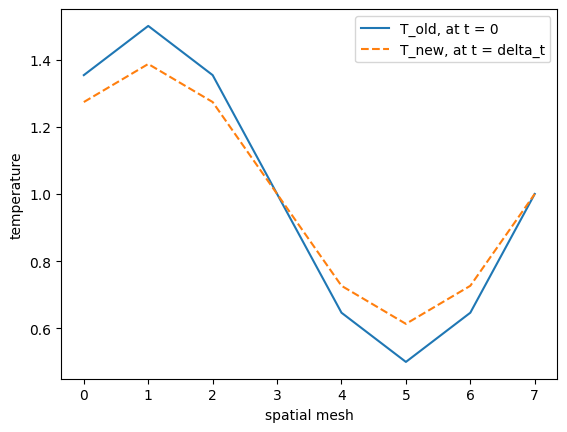

In [3]:
import matplotlib.pyplot as plt
plt.plot(T_old, label='T_old, at t = 0')
plt.plot(T_new, label='T_new, at t = delta_t', linestyle='dashed')
plt.legend()
plt.xlabel('spatial mesh')
plt.ylabel('temperature')
plt.show()

## Preliminaries: direct normalization (by classical solution)

In [4]:
# Normalized linear system A*x_th = b

# T_old
TT_old = np.sum(T_old**2)
b0 = np.sqrt(TT_old)
print(b0)
b = T_old/b0

# T_new
TT_new = np.sum(T_new**2)
x0 = np.sqrt(TT_new)
x_th = T_new/x0 # (theoretical)

# Linear system (normalized)
f = np.sqrt(TT_new/TT_old) 
A = C*f # (normalized)

3.0


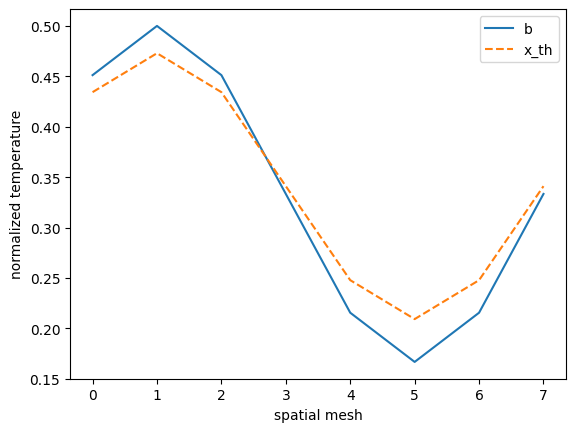

In [5]:
plt.plot(b, label='b')
plt.plot(x_th, label='x_th', linestyle='dashed')
plt.legend()
plt.xlabel('spatial mesh')
plt.ylabel('normalized temperature')
plt.show()

## Quantum observable

In [6]:
# Quantum observable for T_new, or better for |x> (normalized)
# O = A^dag ( I - |b><b| ) A
# <x|O|x> --> 0 (minimum) 
# 
# because A^dag = f C^dag then
# O = f^2 C^dag ( I - |b><b| ) C
# which has the same minimum for |x>
# 
# Ref: PHYSICAL REVIEW A 107, 052422 (2023)
# Depth analysis of variational quantum algorithms for the heat equation

O = np.identity(N)-np.outer(b,b)
O = np.matmul(O,C)
C_dag = np.transpose(C)
O = np.matmul(C_dag,O)

In [7]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info import Operator

observable = SparsePauliOp.from_operator(O)
print(observable)
print(len(observable.paulis))

SparsePauliOp(['III', 'IIX', 'IXI', 'IXX', 'IXZ', 'IYY', 'IZI', 'IZX', 'IZZ', 'XII', 'XIX', 'XXI', 'XXX', 'XXZ', 'XYY', 'XZI', 'XZX', 'XZZ', 'YIY', 'YXY', 'YYI', 'YYX', 'YYZ', 'YZY', 'ZII', 'ZIX', 'ZIZ', 'ZXI', 'ZXX', 'ZXZ', 'ZYY', 'ZZI', 'ZZX', 'ZZZ'],
              coeffs=[ 4.3656726 +0.j, -2.12752751+0.j,  0.12728074+0.j, -1.12752751+0.j,
 -0.01160814+0.j, -1.0164164 +0.j, -0.01160814+0.j, -0.0164164 +0.j,
  0.01160814+0.j, -0.08789482+0.j, -0.09469472+0.j,  0.15049703+0.j,
 -1.09469472+0.j,  0.01160814+0.j,  1.0164164 -0.j,  0.01160814+0.j,
  0.0164164 +0.j, -0.01160814+0.j,  0.01487594-0.j,  0.01487594-0.j,
  0.0359137 -0.j,  0.0359137 -0.j, -0.0359137 +0.j, -0.0359137 +0.j,
 -0.08670334+0.j, -0.08670334+0.j, -0.01487594+0.j, -0.08670334+0.j,
 -0.08670334+0.j, -0.01487594+0.j, -0.0359137 +0.j, -0.0359137 +0.j,
 -0.0359137 +0.j,  0.0359137 +0.j])
34


In [8]:
from numpy.linalg import eigvalsh
eigenvalues = eigvalsh(O)
print(min(eigenvalues))

-6.657273225306448e-16


## Loss/cost function for VQE

In [9]:
def cost_func_vqe(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (Estimator): Estimator primitive instance

    Returns:
        float: Energy estimate
    """
    pub = (ansatz, hamiltonian, params)
    cost = estimator.run([pub]).result()[0].data.evs

    return cost

## Ansatz

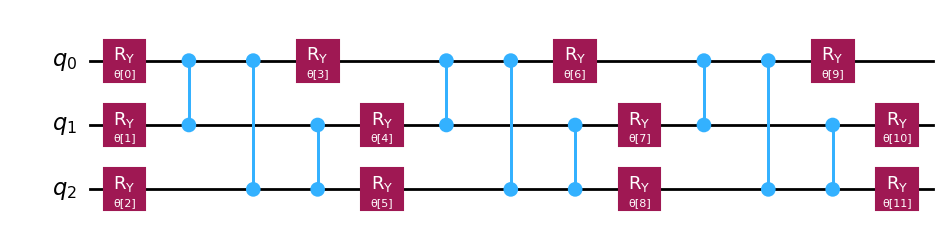

In [10]:
from qiskit.circuit.library import TwoLocal
from qiskit import QuantumCircuit

import numpy as np

num_qubits = n

# Best rational ansatz with minimum number of parameters
raw_ansatz = TwoLocal(num_qubits, rotation_blocks="ry", entanglement_blocks="cz")

raw_ansatz.decompose().draw('mpl')

In [11]:
raw_ansatz.num_parameters

12

## Quantum simulator (qiskit)

In [12]:
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit.primitives import StatevectorSampler as Sampler
import numpy as np

estimator = Estimator()
sampler = Sampler()

# Initial (arbitrary) set of parameter
theta0 = np.ones(raw_ansatz.num_parameters)

## Simulated quantum minimization

In [13]:
# SciPy minimizer routine
from scipy.optimize import minimize
import time

# Variational quantum eigensolver (VQE)
# See https://learning.quantum.ibm.com/tutorial/variational-quantum-eigensolver
start_time = time.time()

result = minimize(cost_func_vqe, theta0, args=(raw_ansatz.decompose(), observable, estimator), 
                  method="COBYLA", 
                  tol = 1e-3, # better tolerance is possible but it would require more iterations/time
                  options={'maxiter': 10000, 'disp': True})
print(result)

end_time = time.time()
execution_time = end_time - start_time
print(f"""Time (s): {execution_time}""")

Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 244   Least value of F = 1.7816997282772348e-06
The corresponding X is:
[1.45637689 1.57825571 1.29740919 0.83866895 1.09876855 0.94641598
 1.99229343 2.14798351 1.27136525 0.99770619 0.94095975 1.20289752]

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: 1.7816997282772348e-06
       x: [ 1.456e+00  1.578e+00  1.297e+00  8.387e-01  1.099e+00
            9.464e-01  1.992e+00  2.148e+00  1.271e+00  9.977e-01
            9.410e-01  1.203e+00]
    nfev: 244
   maxcv: 0.0
Time (s): 1.8491835594177246


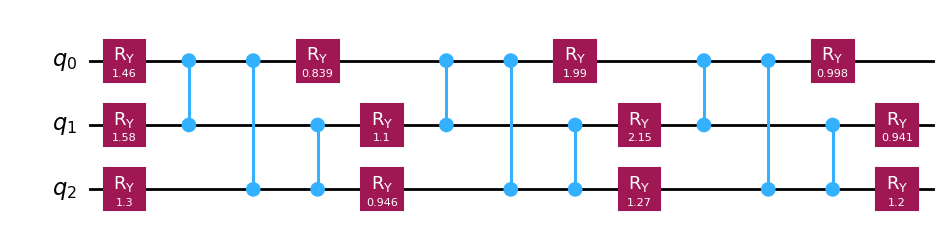

In [14]:
theta = result.x # Final optimized parameters
ansatz = raw_ansatz.assign_parameters(theta)
ansatz.decompose().draw('mpl')

## Simulated quantum results

In [15]:
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

ideal_distribution = Statevector.from_instruction(ansatz).probabilities_dict()

In [16]:
# Solution (quantum)
y = np.real(list(ideal_distribution.values())) # probabilities
x = np.sqrt(y) # amplitudes

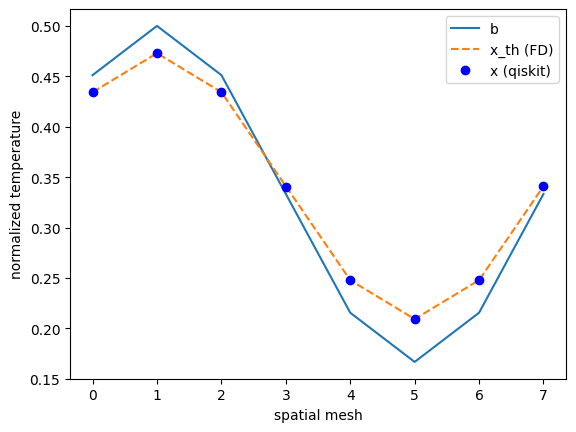

In [17]:
plt.plot(b, label='b')
plt.plot(x_th, label='x_th (FD)', linestyle='dashed')
plt.plot(x, 'bo', label='x (qiskit)')
plt.legend()
plt.xlabel('spatial mesh')
plt.ylabel('normalized temperature')
plt.show()

## De-normalization by post-processing

In [18]:
import statistics

x_mean = statistics.mean(x)
T_mean = statistics.mean(T_old)
scale = T_mean/x_mean
print(f"\nscale = {scale}")

T_new_q = x*scale


scale = 2.9322113546977464


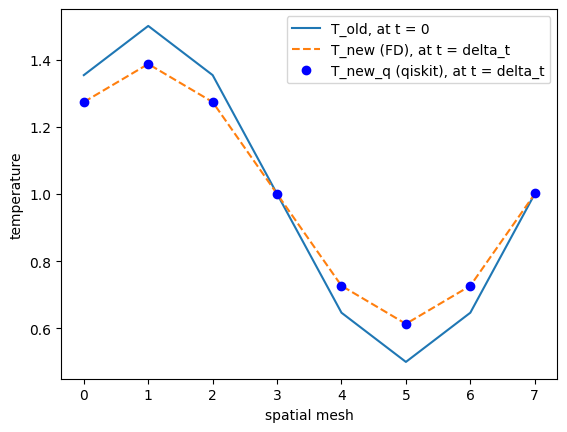

In [19]:
plt.plot(T_old, label='T_old, at t = 0')
plt.plot(T_new, label='T_new (FD), at t = delta_t', linestyle='dashed')
plt.plot(T_new_q, 'bo', label='T_new_q (qiskit), at t = delta_t')
plt.legend()
plt.xlabel('spatial mesh')
plt.ylabel('temperature')
plt.show()

## Simulated quantum results (quantum tea)

In [20]:
def sparse_pauli_to_qtealeaves_dict(sparse_op):
    paulis_list = []
    for pauli, coeff in zip(sparse_op.paulis, sparse_op.coeffs):
        paulis_list.append({
            "label": pauli.to_label(),
            "coeff": {"real": float(coeff.real), "imag": float(coeff.imag)}
        })
    return {"paulis": paulis_list}

In [21]:
import qtealeaves.observables as obs
from qmatchatea import QCOperators, run_simulation

pauli_dict_hamiltonian = sparse_pauli_to_qtealeaves_dict(observable)

obsv = obs.TNObservables()
ham = obs.TNObsWeightedSum.from_pauli_string("hamiltonian", pauli_dict_hamiltonian)
obsv += ham

In [22]:
def vqe_step(theta, ansatz, observables):
    """
    Single step for the vqe: run the circuit
    with a given set of parameters and measure
    the observables.

    Parameters
    ----------
    theta : list
    ansatz : QuantumCircuit
        parametric qiskit quantum circuit
    observables : :class:`TNObservables`
        Observables to measure. There should be an obervable named Hamiltonian

    Returns
    -------
    float
        Expectation value of the hamiltonian
    """

    ansatz.decompose().draw('mpl')

    # Define the Z, X operators
    ops = QCOperators()
    ops["X"] = np.array([[0, 1], [1, 0]])
    ops["Z"] = np.array([[1, 0], [0, -1]])
    # bind the parametric ansatz to the parameters
    binded_ansatz = ansatz.assign_parameters(theta).decompose()
    # Run the simulation
    res = run_simulation(binded_ansatz, observables=observables, operators=ops)

    return np.real(res.observables["hamiltonian"])

In [23]:
vqe_step_opt = lambda x: vqe_step(x, raw_ansatz, obsv)
initial_guess = np.random.normal(np.pi / 2, 0.05, raw_ansatz.num_parameters)

initial_energy = vqe_step_opt(initial_guess)
print(f"Initial energy: {initial_energy}")

res = minimize(vqe_step_opt, initial_guess, method="BFGS")

final_energy = vqe_step_opt(res.x)
print(f"Final energy: {final_energy}, expected {0:.5f}")

Initial energy: 3.2089768585997906


Final energy: 6.37840995298955e-11, expected 0.00000


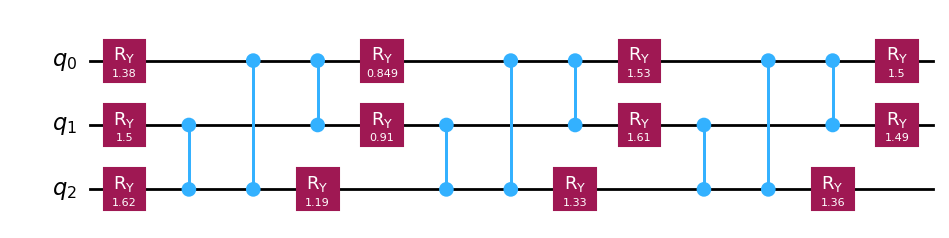

In [24]:
theta = res.x # Final optimized parameters
ansatz = raw_ansatz.assign_parameters(theta)
ansatz_reversed = ansatz.reverse_bits()
ansatz_reversed.decompose().draw('mpl')

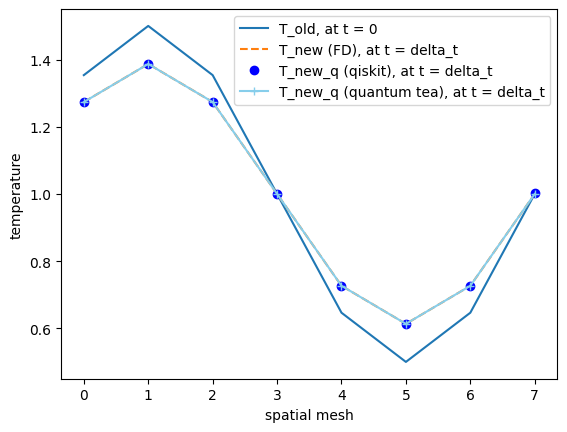

In [25]:
ideal_distribution = Statevector.from_instruction(ansatz_reversed).probabilities_dict()

# Solution (quantum)
y = np.real(list(ideal_distribution.values())) # probabilities
x = np.sqrt(y) # amplitudes

x_mean = statistics.mean(x)
T_mean = statistics.mean(T_old)
scale = T_mean/x_mean
T_new_q_tea = x*scale

plt.plot(T_old, label='T_old, at t = 0')
plt.plot(T_new, label='T_new (FD), at t = delta_t', linestyle='dashed')
plt.plot(T_new_q, 'bo', label='T_new_q (qiskit), at t = delta_t')
plt.plot(T_new_q_tea, color='skyblue', marker='+', label='T_new_q (quantum tea), at t = delta_t')
plt.legend()
plt.xlabel('spatial mesh')
plt.ylabel('temperature')
plt.show()